# Analisis Kualitas Udara dan Sumber Polutan di Bangkalan

## 1. Business Understanding
**Tujuan Proyek:**
Tujuan utama dari analisis ini adalah untuk mengetahui dan memantau tingkat kualitas udara (khususnya polutan berbahaya seperti CO dan NO2) di wilayah Bangkalan, Jawa Timur. Kita akan melihat tren perubahan polutan selama satu tahun terakhir (September 2025 - 31 Agustus 2026).

**Manfaat Proyek:**
1. **Bagi Pemerintah Daerah:** Menjadi dasar evaluasi dan pengambilan kebijakan terkait regulasi emisi kendaraan, terutama di jalur padat seperti akses Jembatan Suramadu.
2. **Bagi Masyarakat:** Memberikan edukasi dan kesadaran (awareness) terkait waktu-waktu dengan kualitas udara terburuk, sehingga masyarakat bisa membatasi aktivitas luar ruangan atau menggunakan masker.
3. **Bagi Lingkungan:** Mengidentifikasi apakah ada aktivitas industri atau pembakaran lahan yang memicu anomali lonjakan polusi secara tiba-tiba di Bangkalan.

In [1]:
import pandas as pd
import requests
import json

# 1. Tentukan Koordinat Bangkalan (Membatasi wilayah)
latitude = -7.03
longitude = 112.74

# 2. Setup Parameter API (Rentang 1 tahun hingga 31 Agustus 2026)
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2025-09-01",
    "end_date": "2026-08-31",
    "hourly": ["carbon_monoxide", "nitrogen_dioxide"]
}

# 3. Crawling Data
response = requests.get(url, params=params)
data = response.json()

# 4. Memasukkan data ke DataFrame
df = pd.DataFrame({
    "tanggal_jam": data['hourly']['time'],
    "CO": data['hourly']['carbon_monoxide'],
    "NO2": data['hourly']['nitrogen_dioxide']
})

# Konversi kolom waktu menjadi tipe datetime
df['tanggal_jam'] = pd.to_datetime(df['tanggal_jam'])

# 5. SIMPAN DATA KE CSV SESUAI SYARAT TUGAS
df.to_csv("data_polutan_bangkalan.csv", index=False)
print("Data berhasil ditarik dan disimpan sebagai 'data_polutan_bangkalan.csv'")

# Tampilkan 5 data teratas
df.head()

Data berhasil ditarik dan disimpan sebagai 'data_polutan_bangkalan.csv'


,tanggal_jam,CO,NO2
0,2025-09-01 00:00:00,760.0,29.7
1,2025-09-01 01:00:00,635.0,23.4
2,2025-09-01 02:00:00,391.0,14.8
3,2025-09-01 03:00:00,207.0,8.1
4,2025-09-01 04:00:00,165.0,5.2


## 2. Data Understanding
Dataset yang ditarik berisi rekaman polusi udara per jam di Bangkalan. Berikut adalah deskripsi fiturnya:

*   **tanggal_jam**: Waktu perekaman data (bertipe datetime).
*   **CO (Karbon Monoksida - μg/m³):** Gas beracun yang tidak berwarna dan tidak berbau. **Sumber utama di Bangkalan:** Asap knalpot kendaraan bermotor (terutama di jalur utama lalu lintas antarkota/Suramadu) dan pembakaran sampah terbuka.
*   **NO2 (Nitrogen Dioksida - μg/m³):** Gas berbau tajam yang bisa merusak saluran pernapasan. **Sumber utama di Bangkalan:** Aktivitas pembakaran bahan bakar fosil dari kendaraan berat (truk/bus) dan aktivitas industri.

**Eksplorasi Data Aneh (Anomali):**
Terkadang alat sensor satelit/API mencatat angka yang tidak masuk akal (misalnya nilai polutan negatif atau `NaN` / kosong karena gangguan cuaca tebal). Kita harus mengeceknya di tahap persiapan data.

In [2]:
# Mengecek apakah ada nilai kosong (NaN)
print("Jumlah data kosong:\n", df.isnull().sum())

# Mengecek apakah ada data aneh (nilai polutan minus yang tidak masuk akal di dunia nyata)
data_aneh = df[(df['CO'] < 0) | (df['NO2'] < 0)]
print(f"Jumlah data anomali (negatif): {len(data_aneh)}")

Jumlah data kosong:
 tanggal_jam    0
CO             0
NO2            0
dtype: int64
Jumlah data anomali (negatif): 0


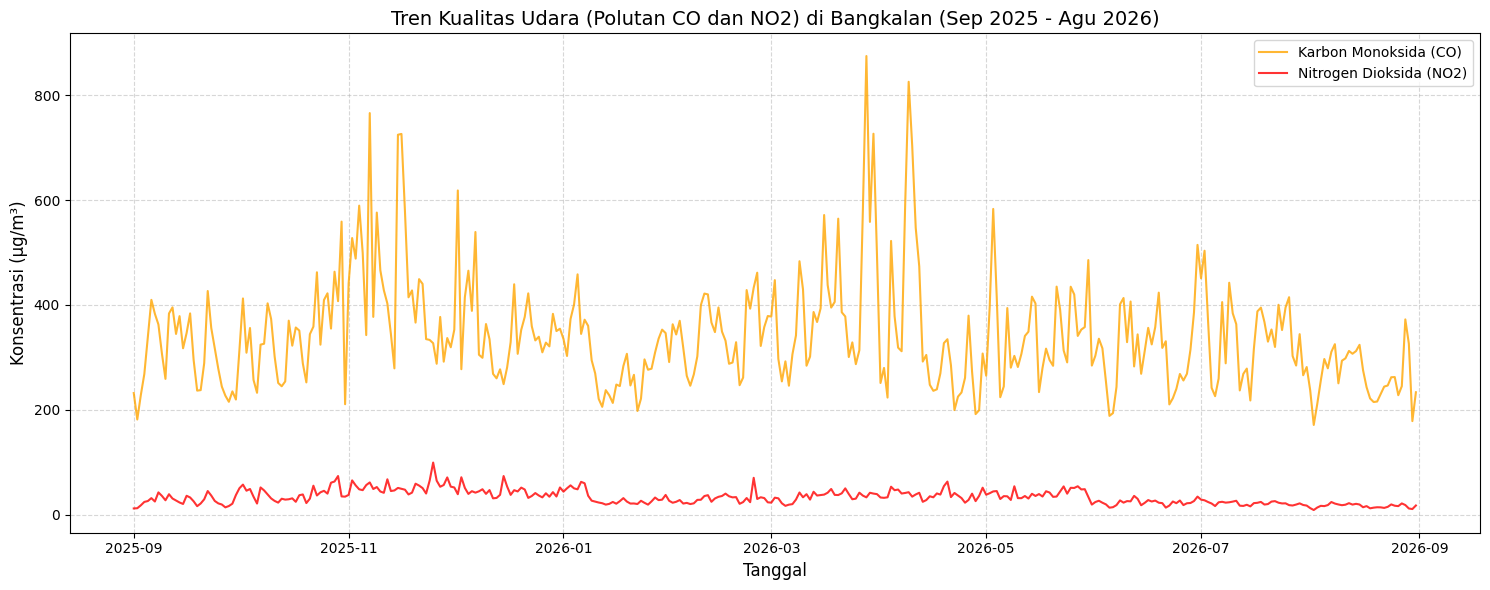

In [3]:
import matplotlib.pyplot as plt

# Agar grafik lebih rapi, kita hitung rata-rata harian
df_harian = df.set_index('tanggal_jam').resample('D').mean()

# Membuat Grafik Time Series
plt.figure(figsize=(15, 6))

# Plot CO (Kita buat skala CO pada sumbu y yang berbeda jika nilainya terlalu njomplang, 
# tapi untuk kesederhanaan kita plot di satu grafik dulu)
plt.plot(df_harian.index, df_harian['CO'], label='Karbon Monoksida (CO)', color='orange', alpha=0.8)
plt.plot(df_harian.index, df_harian['NO2'], label='Nitrogen Dioksida (NO2)', color='red', alpha=0.8)

plt.title('Tren Kualitas Udara (Polutan CO dan NO2) di Bangkalan (Sep 2025 - Agu 2026)', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Tampilkan Grafik
plt.show()